In [27]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector 
import matplotlib.pyplot as plt
from qiskit.visualization import plot_state_qsphere
from IPython.display import display

### Deutsch's Algorithm: Proving Quantum Advantage

**1. The Objective: The Oracle Problem **
Imagine a closed-source function, or "Black Box" Oracle, denoted as $f(x)$. It takes a single classical bit as input ($0$ or $1$) and returns a single classical bit. 
Because there are only four possible 1-bit functions, the Oracle must fall into one of two categories:
* **Constant:** It returns the same output regardless of the input (e.g., $f(x) = 0$ always, or $f(x) = 1$ always).
* **Balanced:** It returns $0$ exactly half the time and $1$ exactly half the time (e.g., $f(x) = x$, or $f(x) = \text{NOT } x$).

The goal is to determine whether the Oracle is Constant or Balanced with the absolute minimum number of queries.

**2. The Classical Limitation **
A classical computer is strictly bound by sequential logic. To classify the function, it must evaluate $f(0)$, store the result, and then evaluate $f(1)$. If the outputs match, it is Constant; if they differ, it is Balanced. It takes a minimum of **two queries** to be 100% certain.

**3. The Quantum Advantage **
Deutsch's Algorithm demonstrates true quantum advantage by solving this exact problem in exactly **one query**. It achieves this by leveraging two fundamental quantum phenomena: Superposition and Phase Kickback.

**4. The Core Mechanism: Phase Kickback **
In a quantum circuit, the Oracle is implemented as a unitary operator $U_f$ that acts on two qubits: an input ($|x\rangle$) and a target ($|y\rangle$). It performs the operation:
$$|x\rangle|y\rangle \xrightarrow{U_f} |x\rangle|y \oplus f(x)\rangle$$

The secret to Deutsch's algorithm is initializing the target qubit in the negative superposition state $|-\rangle$. When $U_f$ is applied, it cannot flip $|-\rangle$ into anything else. Instead, it "kicks back" a negative phase $(-1)^{f(x)}$ to the input qubit.

**5. The Mathematical Protocol **
* **Initialization:** We prepare two qubits. The input ($q_0$) is set to $|+\rangle$, and the target ($q_1$) is set to $|-\rangle$.
* **The Oracle ($U_f$):** We pass both qubits through the Black Box. Because $q_0$ is in superposition, we evaluate both $f(0)$ and $f(1)$ simultaneously. Due to phase kickback, the input qubit state transforms into:
  $$\frac{1}{\sqrt{2}} \left( (-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle \right)$$
* **Interference:** We apply a final Hadamard ($H$) gate to the input qubit. 
    * If $f(x)$ is **Constant**, the global phase cancels out, and the $H$ gate perfectly returns the qubit to $|0\rangle$.
    * If $f(x)$ is **Balanced**, a relative phase shift flips the qubit to the $|-\rangle$ state, and the final $H$ gate transforms it into $|1\rangle$.
* **Measurement:** We measure $q_0$. A result of $0$ mathematically guarantees a Constant Oracle. A result of $1$ mathematically guarantees a Balanced Oracle.

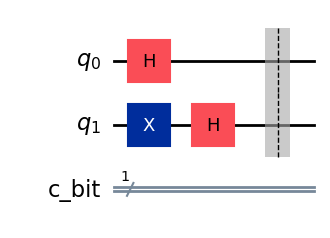

In [28]:
qr = QuantumRegister(2, 'q')
c_bit = ClassicalRegister(1, 'c_bit')
qc = QuantumCircuit(qr, c_bit)

qc.h(0)


qc.x(1)
qc.h(1)

qc.barrier()
qc.draw('mpl')

### Constant Blackbox

In [29]:
const_oracle = QuantumCircuit(2, name='Constant')
const_oracle.x(1)

### Balanced Blackbox

In [30]:
bal_oracle = QuantumCircuit(2, name='Balanced')
bal_oracle.cx(0,1) 


### We can change here which black box we want to use

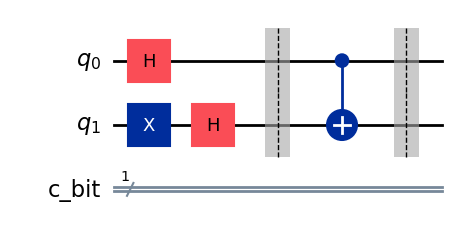

In [31]:
qc = qc.compose(bal_oracle, qubits=[0, 1])

qc.barrier()
qc.draw('mpl')

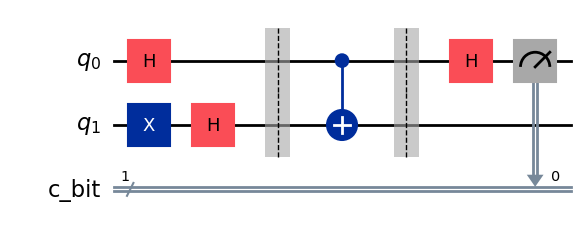

In [32]:
qc.h(0)

qc.measure(0,0)

qc.draw('mpl')

Algorithm Output: {'1': 1000}


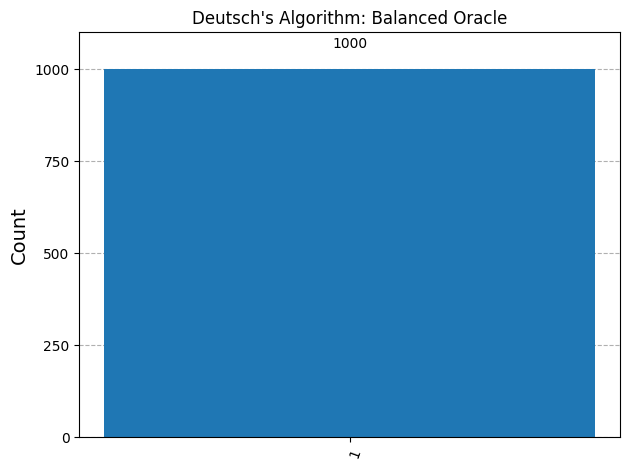

In [33]:
sim = AerSimulator()
job = sim.run(qc, shots=1000)
counts = job.result().get_counts()

# 8. Display the results
print("Algorithm Output:", counts)
plot_histogram(counts, title="Deutsch's Algorithm: Balanced Oracle")